# RaCo Simple Keypoint Extraction Demo

First load the image and a RaCo extractor

In [9]:
import torch
from raco import RaCo
from raco.utils import load_image


device = "cuda" if torch.cuda.is_available() else "cpu"
image = load_image("assets/i_castle.png")

# Initialize a RaCo extractor with the default configuration
extractor = RaCo()

In [10]:
output = extractor.extract(image)
print("Output keys:", [k for k in output.keys()])

Output keys: ['keypoints', 'keypoint_scores', 'ranker_scores', 'covariances', 'image_size']


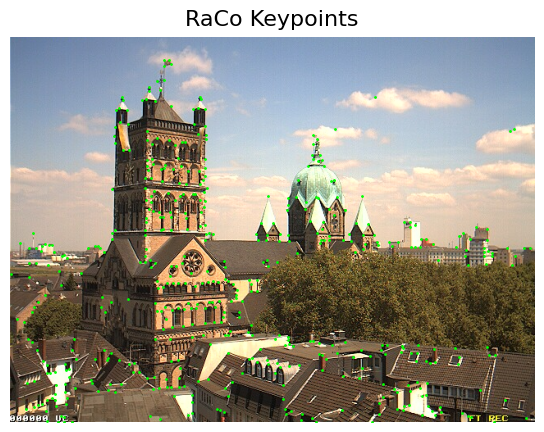

In [11]:
from raco import viz2d
import matplotlib.pyplot as plt

ax = viz2d.plot_images([image])
viz2d.plot_keypoints([output["keypoints"][0]], axes=ax)

plt.suptitle("RaCo Keypoints", fontsize=16, y=0.95)
plt.tight_layout()

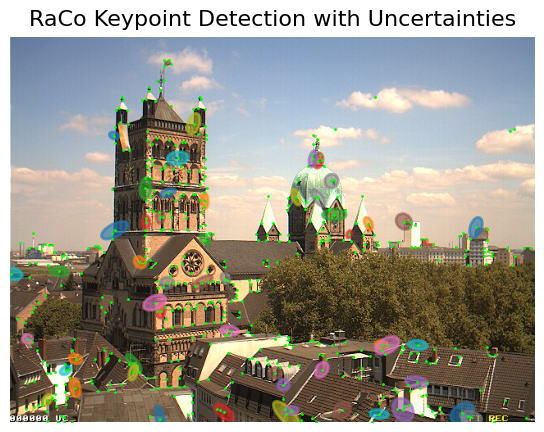

In [12]:
ax = viz2d.plot_images([image])

# Subsample keypoints for cleaner visualization
subsample = 10
idxs = torch.randperm(
    len(output["keypoints"][0]), generator=torch.Generator().manual_seed(42)
)[::subsample]

keypoints = output["keypoints"][0]
subsampled_keypoints = output["keypoints"][0][idxs]
subsampled_covariances = output["covariances"][0][idxs]

viz2d.plot_covariance_ellipses(
    [subsampled_keypoints],
    [subsampled_covariances],
    axes=ax,
    sigma=20,
)

viz2d.plot_keypoints(
    [keypoints],
    axes=ax,
)

plt.suptitle("RaCo Keypoint Detection with Uncertainties", fontsize=16, y=0.95)
plt.tight_layout()